In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_churn_feature_engineered.csv")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip_Code,Lat_Long,Latitude,Longitude,Gender,...,Tenure_Group,Monthly_Charge_Category,CLTV_Category,Total_Services,High_Value_Customer,Customer_Segment,Risk_Level,Revenue_Category,Customer_Age_Group,Customer_Status
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,0-12 Months,Medium,Low,3,No,Silver,High Risk,Low,Adult,Inactive
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,0-12 Months,High,Low,1,No,Standard,Medium Risk,Low,Adult,Inactive
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,0-12 Months,High,High,5,Yes,Premium,High Risk,Medium,Adult,Inactive
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,25-48 Months,High,Medium,6,Yes,Premium,High Risk,High,Adult,Inactive
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,49-72 Months,High,High,6,Yes,Premium,High Risk,High,Adult,Inactive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               7043 non-null   object 
 1   Count                    7043 non-null   int64  
 2   Country                  7043 non-null   object 
 3   State                    7043 non-null   object 
 4   City                     7043 non-null   object 
 5   Zip_Code                 7043 non-null   int64  
 6   Lat_Long                 7043 non-null   object 
 7   Latitude                 7043 non-null   float64
 8   Longitude                7043 non-null   float64
 9   Gender                   7043 non-null   object 
 10  Senior_Citizen           7043 non-null   object 
 11  Partner                  7043 non-null   object 
 12  Dependents               7043 non-null   object 
 13  Tenure_Months            7043 non-null   int64  
 14  Phone_Service           

In [5]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn_Reason', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Risk_Level', 'Revenue_Category', 'Customer_Age_Group', 'Customer_Status']


In [6]:
df = df.drop(
    columns=[
        "Churn_Label",
        "Churn_Score",
        "Customer_Status",
        "Risk_Level"
    ],
    errors="ignore"
)

In [7]:
X = df.drop("Churn_Value", axis=1)

y = df["Churn_Value"]

In [8]:
categorical_columns = X.select_dtypes(include=["object"]).columns

categorical_columns

Index(['CustomerID', 'Country', 'State', 'City', 'Lat_Long', 'Gender',
       'Senior_Citizen', 'Partner', 'Dependents', 'Phone_Service',
       'Multiple_Lines', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV',
       'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method',
       'Churn_Reason', 'Tenure_Group', 'Monthly_Charge_Category',
       'CLTV_Category', 'High_Value_Customer', 'Customer_Segment',
       'Revenue_Category', 'Customer_Age_Group'],
      dtype='object')

In [9]:
le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
dt_predictions = dt_model.predict(X_test)

In [13]:
print("Accuracy :", accuracy_score(y_test, dt_predictions))

Accuracy : 1.0


In [14]:
print("Precision :", precision_score(y_test, dt_predictions))

Precision : 1.0


In [15]:
print("Recall :", recall_score(y_test, dt_predictions))

Recall : 1.0


In [16]:
print("F1 Score :", f1_score(y_test, dt_predictions))

F1 Score : 1.0


In [17]:
print("ROC AUC :", roc_auc_score(y_test, dt_predictions))

ROC AUC : 1.0


In [18]:
cm = confusion_matrix(y_test, dt_predictions)

print(cm)

[[1009    0]
 [   0  400]]


In [19]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Value', 'CLTV', 'Churn_Reason', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Revenue_Category', 'Customer_Age_Group']


In [20]:
# Target
y = df["Churn_Value"]

# Features
X = df.drop(
    columns=[
        "Churn_Value",
        "Churn_Label",
        "Churn_Score",
        "Customer_Status",
        "Churn_Category",
        "Churn_Reason"
    ],
    errors="ignore"
)

In [21]:
from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(include=["object"]).columns

le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
dt_predictions = dt_model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision :", precision_score(y_test, dt_predictions))
print("Recall :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))
print("ROC AUC :", roc_auc_score(y_test, dt_predictions))

Accuracy : 0.78708303761533
Precision : 0.5906862745098039
Recall : 0.6443850267379679
F1 Score : 0.6163682864450127
ROC AUC : 0.7415161848665686


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_predictions)

print(cm)

[[868 167]
 [133 241]]


In [27]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                    Feature  Importance
23                 Contract    0.483122
17          Online_Security    0.130097
12               Dependents    0.107598
27            Total_Charges    0.075926
13            Tenure_Months    0.073561
16         Internet_Service    0.054157
26          Monthly_Charges    0.044090
5                  Zip_Code    0.015508
28                     CLTV    0.008553
0                CustomerID    0.004197
25           Payment_Method    0.003192
21             Streaming_TV    0.000000
29             Tenure_Group    0.000000
30  Monthly_Charge_Category    0.000000
31            CLTV_Category    0.000000


In [28]:
print(X.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip_Code', 'Lat_Long', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'CLTV', 'Tenure_Group', 'Monthly_Charge_Category', 'CLTV_Category', 'Total_Services', 'High_Value_Customer', 'Customer_Segment', 'Revenue_Category', 'Customer_Age_Group']


In [29]:
X = X.drop(
    columns=[
        "CustomerID",
        "Count",
        "Country",
        "State",
        "City",
        "Zip_Code",
        "Lat_Long",
        "Latitude",
        "Longitude"
    ],
    errors="ignore"
)

In [30]:
categorical_columns = X.select_dtypes(include=["object"]).columns

print(categorical_columns)

Index([], dtype='object')


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

print("Encoding Completed")

Encoding Completed


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
dt_predictions = dt_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy :", accuracy_score(y_test, dt_predictions))
print("Precision :", precision_score(y_test, dt_predictions))
print("Recall :", recall_score(y_test, dt_predictions))
print("F1 Score :", f1_score(y_test, dt_predictions))
print("ROC AUC :", roc_auc_score(y_test, dt_predictions))

Accuracy : 0.7849538679914834
Precision : 0.585956416464891
Recall : 0.6470588235294118
F1 Score : 0.6149936467598475
ROC AUC : 0.740920716112532


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_predictions)

print(cm)

[[864 171]
 [132 242]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1035
           1       0.59      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



In [38]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

             Feature  Importance
14          Contract    0.491380
8    Online_Security    0.132068
3         Dependents    0.109741
4      Tenure_Months    0.087775
18     Total_Charges    0.059898
7   Internet_Service    0.054977
17   Monthly_Charges    0.044758
19              CLTV    0.007364
2            Partner    0.006723
16    Payment_Method    0.003241
0             Gender    0.002074
11      Tech_Support    0.000000
20      Tenure_Group    0.000000
26  Revenue_Category    0.000000
25  Customer_Segment    0.000000


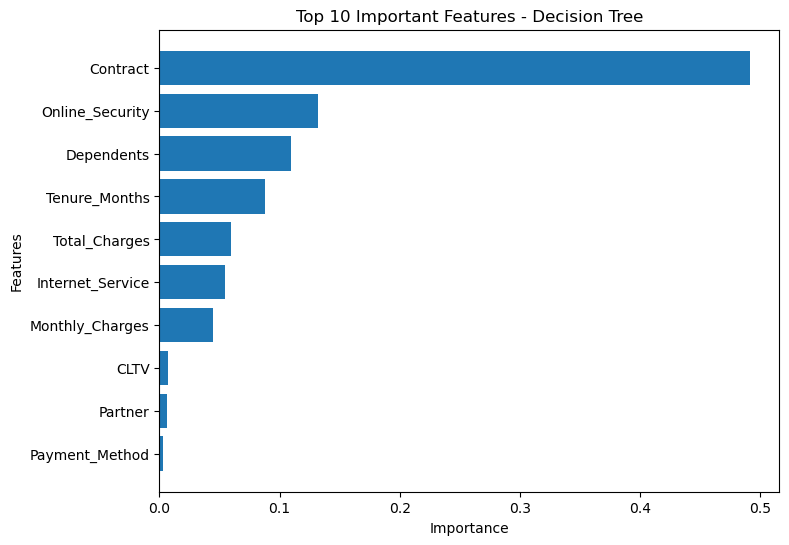

In [39]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Decision Tree")
plt.gca().invert_yaxis()
plt.show()

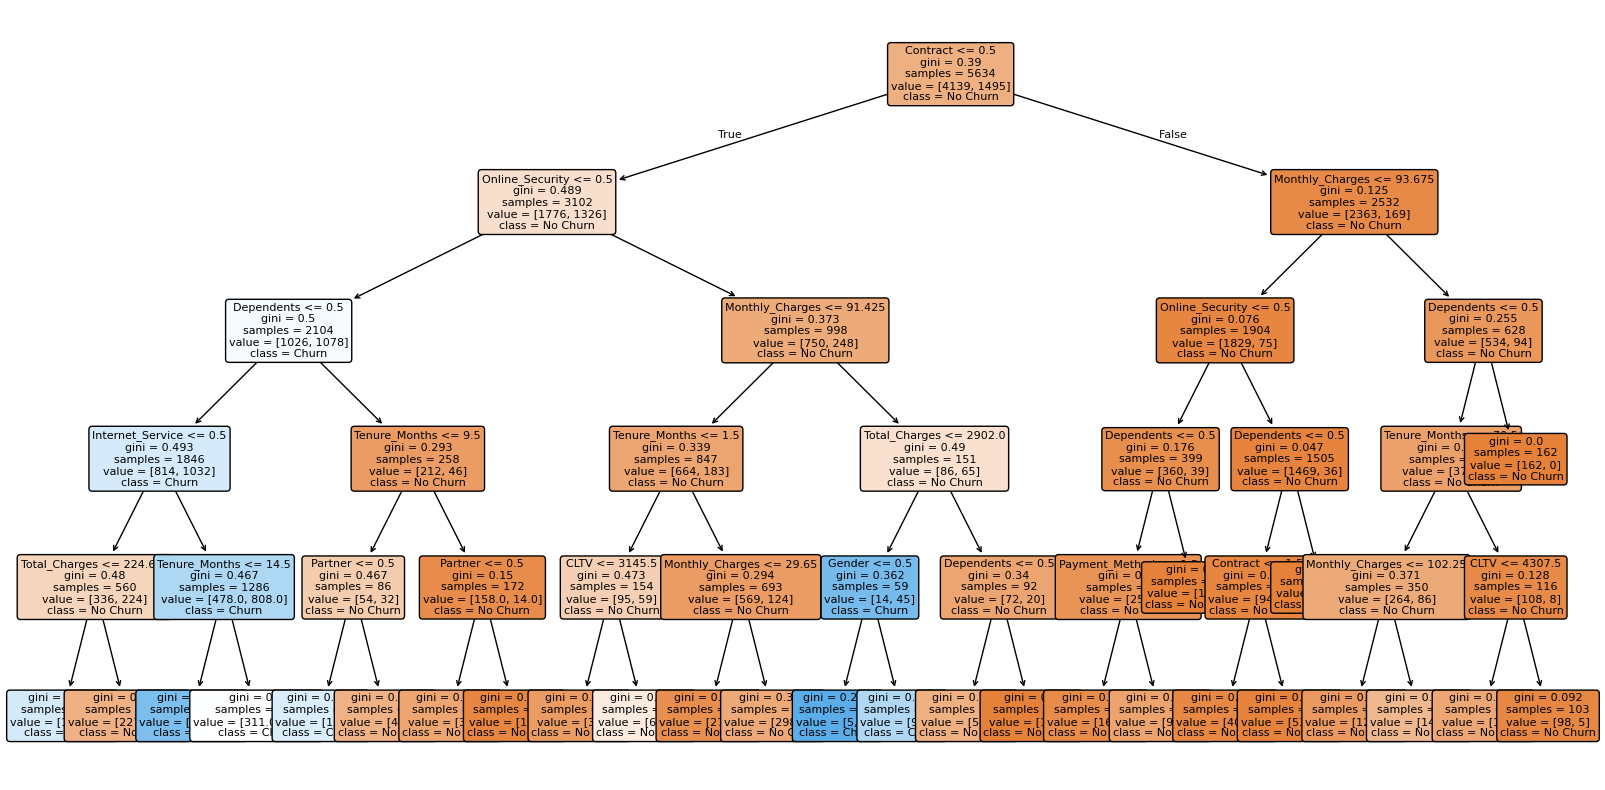

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()